<p style="text-align:right;">Mario Stanke, University of Greifswald, Germany</p>

# Solution to Session 3 - Exercise 0 - A Conv1D Classifier for Genomic Sequences

We train a **single** `Conv1d` layer to label every nucleotide position in a DNA window with one of five classes:

| label | meaning |
|-------|---------|
| 0 | background |
| 1 | gene start |
| 2 | gene end |
| 3 | exon start |
| 4 | exon end |

The model is literally one `Conv1d(in_channels=4, out_channels=5, kernel_size=7)` — no hidden layers, no activation function, no pooling.

In [6]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

from genome_batch_generator import make_batch_generator

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cpu


## The Data

Each training example is a short genomic DNA window.  
The input **x** is a one-hot encoded matrix of shape `(4, L)`:  
one row per nucleotide letter (A, C, G, T in that order), one column per position.  
The target **y** is an integer label sequence of shape `(L,)` with values 0–4.

In [7]:
SHARDS_DIR = '../../../data/genome/'
BATCH_SIZE = 64
NUM_CLASSES = 5
L = 100  # fixed window length for shards_short

train_loader = make_batch_generator(SHARDS_DIR, split='train', batch_size=BATCH_SIZE, shuffle=True)

# peek at the first batch
x_batch, y_batch, meta = next(iter(train_loader))
print('x_batch shape:', x_batch.shape)   # (B, 4, L)
print('y_batch shape:', y_batch.shape)   # (B, L)
print('L =', x_batch.shape[2])           # confirm L
print('dtype x:', x_batch.dtype, '  dtype y:', y_batch.dtype)
print('example metadata:', meta['chrom'][0], 'start:', meta['start'][0].item())

NameError: name 'DataLoader' is not defined

In [68]:
# Decode the first sequence: convert one-hot back to nucleotide letters
BASES = ['A', 'C', 'G', 'T']  # channel order
x0 = x_batch[0]              # shape (4, L)
y0 = y_batch[0]              # shape (L,)

base_indices = x0.argmax(dim=0)   # most likely base at each position
seq = ''.join(BASES[i] for i in base_indices[:L].tolist())
labels_str = ''.join(str(int(v)) for v in y0[:L].tolist())

print('sequence:'); print(seq)
print('labels:  '); print(labels_str)
print()
print('label class counts in this window:')
for c in range(NUM_CLASSES):
    print(f'  class {c}: {(y0 == c).sum().item()} positions')

sequence:
ACAGCCATCCGCAATGGACAGGTGTGGGAGGAGTCTTTAAAGAGACTGAGGCAGAAGGCATCCTTGACCAATGTCACAGGTACAGAAAACCCACCAGCCC
labels:  
0000000000000000000000000000000000000000000000000000000000000000000000000000004000000000000000000000

label class counts in this window:
  class 0: 99 positions
  class 1: 0 positions
  class 2: 0 positions
  class 3: 0 positions
  class 4: 1 positions


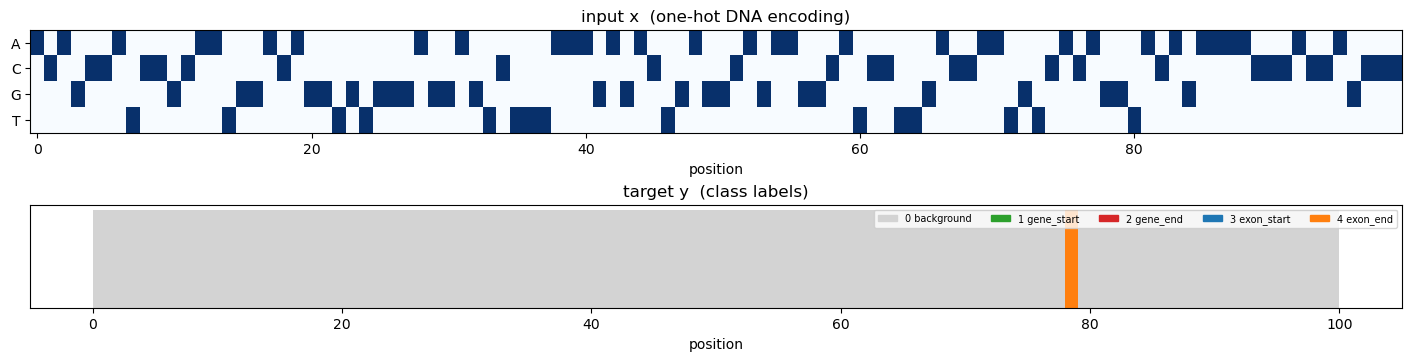

In [69]:
# Visualize the one-hot matrix and the label sequence for the full window
fig, axes = plt.subplots(2, 1, figsize=(14, 3.5), constrained_layout=True)

# top panel: one-hot encoding (4 x L)
ax = axes[0]
ax.imshow(x0[:, :L].numpy(), aspect='auto', interpolation='nearest',
          cmap='Blues', origin='upper')
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels(BASES)
ax.set_xlabel('position')
ax.set_title('input x  (one-hot DNA encoding)')

# bottom panel: label sequence
ax = axes[1]
colors = ['lightgrey', 'tab:green', 'tab:red', 'tab:blue', 'tab:orange']
label_names = ['background', 'gene_start', 'gene_end', 'exon_start', 'exon_end']
for pos, lbl in enumerate(y0[:L].numpy()):
    ax.bar(pos, 1, color=colors[lbl], width=1.0, align='edge')
# legend
from matplotlib.patches import Patch
legend_handles = [Patch(color=colors[c], label=f'{c} {label_names[c]}') for c in range(NUM_CLASSES)]
ax.legend(handles=legend_handles, loc='upper right', fontsize=7, ncol=5)
ax.set_yticks([])
ax.set_xlabel('position')
ax.set_title('target y  (class labels)');

## The Model

A single `Conv1d` with:
- **4 input channels** — one per nucleotide letter (A, C, G, T)
- **5 output channels** — one score per class, at every position
- **kernel size 7** — the filter looks at 7 consecutive nucleotides at a time
- `padding='same'` — output length equals input length

The weight tensor has shape `[5, 4, 7]` = 140 parameters total.

Forward pass: `x` of shape `(B, 4, L)` → conv → `(B, 5, L)` → transpose → `(B, L, 5)`  
The last dimension holds the five class logits for each position.

In [70]:
torch.manual_seed(0)

KERNEL_SIZE = 7

conv = nn.Conv1d(
    in_channels=4,
    out_channels=NUM_CLASSES,
    kernel_size=KERNEL_SIZE,
    padding='same',
    bias=False,
).to(device)

print(conv)
total_params = sum(p.numel() for p in conv.parameters())
print(f'trainable parameters: {total_params}  (= {NUM_CLASSES} × 4 × {KERNEL_SIZE})')

Conv1d(4, 5, kernel_size=(7,), stride=(1,), padding=same, bias=False)
trainable parameters: 140  (= 5 × 4 × 7)


## Training

The `train_loader` iterates over a large portion of the human genome, that is enriched for gene starts, gene ends, exon starts, and exon ends.
We use weighted cross-entropy loss because the classes are very imbalanced — the background class (0) dominates.  
We train for **one epoch** only.

In [71]:
# up-weight the rare signal classes
class_weights = torch.tensor([1.0, 10.0, 10.0, 2.0, 2.0], device=device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(conv.parameters(), lr=0.05)

In [72]:
conv.train()

total_batches = len(train_loader)
print_every = max(1, total_batches // 10)
loss_history = []

for batch_idx, (x, y, _) in enumerate(train_loader, start=1):
    x = x.to(device)   # (B, 4, L)
    y = y.to(device)   # (B, L)

    optimizer.zero_grad()

    logits = conv(x).transpose(1, 2)          # (B, L, 5)
    loss = criterion(logits.reshape(-1, NUM_CLASSES), y.reshape(-1))

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if batch_idx == 1 or batch_idx % print_every == 0 or batch_idx == total_batches:
        print(f'  batch {batch_idx:4d}/{total_batches}  loss={loss.item():.4f}')


  batch    1/486  loss=1.6281
  batch   48/486  loss=0.1561
  batch   96/486  loss=0.1014
  batch  144/486  loss=0.0752
  batch  192/486  loss=0.0779
  batch  240/486  loss=0.0755
  batch  288/486  loss=0.0692
  batch  336/486  loss=0.0920
  batch  384/486  loss=0.0594
  batch  432/486  loss=0.0648
  batch  480/486  loss=0.0640
  batch  486/486  loss=0.0622


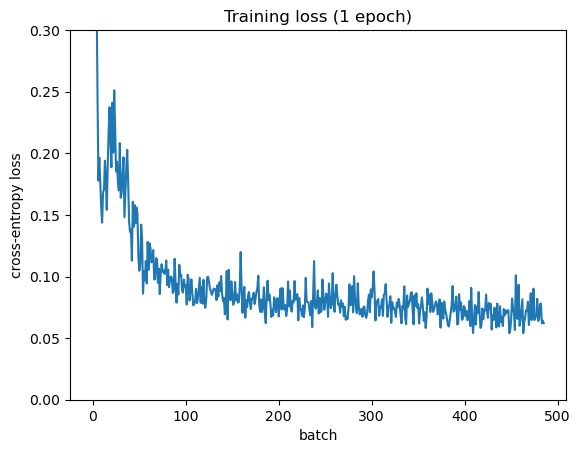

In [73]:
plt.plot(loss_history)
plt.ylim(0, 0.3)
plt.xlabel('batch')
plt.ylabel('cross-entropy loss')
plt.title('Training loss (1 epoch)');

## Inspect the Learned Filter Weights

The weight tensor has shape `[num_classes, in_channels, kernel_size]` = `[5, 4, 7]`.  
Axis 0 selects the class, axis 1 selects the nucleotide (A/C/G/T), axis 2 selects the kernel position.

Each row of the heatmap below shows which nucleotides at which relative positions push the score for that class up (red) or down (blue).

In [74]:
# Print weight summary
weight = conv.weight.detach().cpu()   # [5, 4, 7] = [class, base, kernel_pos]
print(f'weight shape: {tuple(weight.shape)}  # [class, base, kernel_pos]')
print('weight:')
print(weight.numpy().round(3))

weight shape: (5, 4, 7)  # [class, base, kernel_pos]
weight:
[[[ 0.511  0.109  0.647  0.655  1.319  0.815  0.076]
  [ 0.396  0.507  0.755  1.238  1.273  1.111  0.965]
  [ 0.576  0.666  0.408  0.96   0.73   0.227  0.339]
  [ 0.536  0.872  1.11   1.379  0.029  0.735  0.955]]

 [[ 0.195 -0.871 -0.96   1.373 -2.09  -1.838 -1.38 ]
  [-1.059  0.077 -0.15  -2.346 -1.345 -1.652 -0.779]
  [ 0.031 -0.638 -0.694 -2.596 -2.374  1.828 -0.317]
  [-1.287 -0.743 -0.993 -1.926  1.347 -1.926 -0.992]]

 [[-0.438 -0.524 -0.402 -1.65  -1.683  1.116  0.986]
  [-0.007 -0.246 -0.274 -0.392 -1.528 -1.983 -1.769]
  [ 0.04  -0.012 -1.097 -0.902 -1.789  0.233 -0.155]
  [-0.38  -0.276 -0.253 -0.847  1.587 -2.124 -2.119]]

 [[-1.721  1.718 -2.047 -1.34  -0.049 -0.241 -0.561]
  [ 0.436 -1.505 -1.657 -1.234 -0.245  0.244  0.382]
  [-2.766 -2.054  1.883 -0.412 -0.725 -0.901 -0.398]
  [ 0.604 -2.143 -1.927 -1.193 -0.813  0.013  0.239]]

 [[-0.179 -0.4    0.031 -2.049 -1.769 -2.237  0.46 ]
  [-0.416 -0.079 -0.609 -1.351

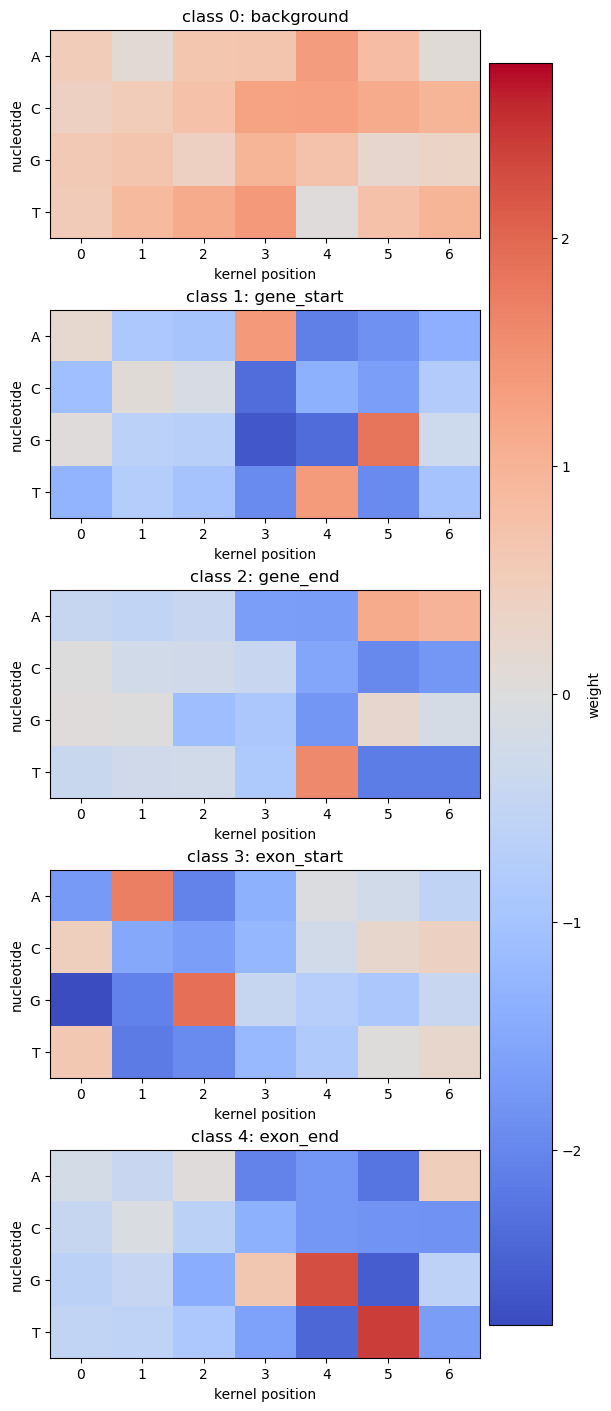

In [75]:
# Plot one heatmap per class
CLASS_NAMES = ['background', 'gene_start', 'gene_end', 'exon_start', 'exon_end']

vabs = float(weight.abs().max().item())
if vabs == 0.0:
    vabs = 1.0

fig, axes = plt.subplots(NUM_CLASSES, 1, figsize=(6, 2.8 * NUM_CLASSES),
                         squeeze=False, constrained_layout=True)

image = None
for class_idx in range(NUM_CLASSES):
    ax = axes[class_idx, 0]
    image = ax.imshow(
        weight[class_idx].numpy(),   # shape (4, 7)
        aspect='auto',
        interpolation='nearest',
        cmap='coolwarm',
        vmin=-vabs,
        vmax=vabs,
        origin='upper',
    )
    ax.set_title(f'class {class_idx}: {CLASS_NAMES[class_idx]}')
    ax.set_xlabel('kernel position')
    ax.set_ylabel('nucleotide')
    ax.set_yticks([0, 1, 2, 3])
    ax.set_yticklabels(BASES)

if image is not None:
    fig.colorbar(image, ax=axes, shrink=0.95, label='weight', location='right', pad=0.02)

## Improve the Convolutional Neural Network
 1. Increase the kernel size.
 2. Add additional convolutional layers with non-linearities in between.
 3. Increase the receptive field of the model, i.e. the number of input positions that can influence the output at a given position, by 

    - a) using pooling layers with a stride > 1 or
    - b) dilated convolutions.

Aim at a validation F1 score of **class 3 == "exon end" of at least 0.4**. 
The interpretability of the weights may be lost, however, and we need not visualize weights. 



## ConvMLPClassifier

`ConvMLPClassifier` stacks three dilated `Conv1d` layers with ReLU activations followed by a two-layer MLP head applied independently at every position:

```
Conv1d(4 → 32, k=15, pad=same)  → ReLU
Conv1d(32 → 32, k=15, dilation=9, pad=same) → ReLU
Conv1d(32 → 32, k=15, dilation=3, pad=same) → ReLU
Linear(32 → 64) → ReLU → Linear(64 → 5)
```

The dilated convolutions greatly expand the receptive field without extra parameters:
- layer 1 receptive field: **15**
- layer 2 adds dilation=9 → covers **9·(15-1)+15 = 141** positions from the original sequence
- layer 3 adds dilation=3 → covers **3·(15-1)+15 = 57** positions of layer-2 output, which itself already integrates 141 original positions

In [94]:
from src.models.conv_mlp import ConvMLPClassifier

torch.manual_seed(0)

model = ConvMLPClassifier(
    in_channels=4,
    conv_channels=16,
    kernel_size=5,
    dilation=3,
    second_dilation=3,
    hidden_dim=8,
    num_classes=NUM_CLASSES,
).to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'trainable parameters: {total_params:,}')

ConvMLPClassifier(
  (features): Sequential(
    (0): Conv1d(4, 16, kernel_size=(5,), stride=(1,), padding=same)
    (1): ReLU()
    (2): Conv1d(16, 16, kernel_size=(5,), stride=(1,), padding=same, dilation=(3,))
    (3): ReLU()
    (4): Conv1d(16, 16, kernel_size=(5,), stride=(1,), padding=same, dilation=(3,))
    (5): ReLU()
  )
  (classifier): Sequential(
    (0): Linear(in_features=16, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=5, bias=True)
  )
)
trainable parameters: 3,109


## Training

We reuse the same weighted cross-entropy loss.  
The training loop is extracted into `train_one_epoch` so it can be called for multiple epochs without code repetition.  
We also create a validation loader to track generalisation.

In [95]:
def train_one_epoch(model, loader, criterion, optimizer, device, print_every=None):
    """Run one full pass over `loader`, return per-batch loss list."""
    model.train()
    total_batches = len(loader)
    if print_every is None:
        print_every = max(1, total_batches // 10)
    loss_history = []
    for batch_idx, (x, y, _) in enumerate(loader, start=1):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)                                      # (B, L, C)
        loss = criterion(logits.reshape(-1, NUM_CLASSES), y.reshape(-1))
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())
        if batch_idx == 1 or batch_idx % print_every == 0 or batch_idx == total_batches:
            print(f'  batch {batch_idx:4d}/{total_batches}  loss={loss.item():.4f}')
    return loss_history


val_loader = make_batch_generator(SHARDS_DIR, split='val', batch_size=BATCH_SIZE, shuffle=False)

optimizer = torch.optim.Adam(model.parameters(), lr=0.02)

In [96]:
NUM_EPOCHS = 1
all_loss = []

for epoch in range(1, NUM_EPOCHS + 1):
    print(f'\n--- epoch {epoch}/{NUM_EPOCHS} ---')
    epoch_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    all_loss.extend(epoch_loss)


--- epoch 1/1 ---
  batch    1/486  loss=1.4230
  batch   48/486  loss=0.1643
  batch   96/486  loss=0.1370
  batch  144/486  loss=0.1569
  batch  192/486  loss=0.1127
  batch  240/486  loss=0.0981
  batch  288/486  loss=0.1311
  batch  336/486  loss=0.0781
  batch  384/486  loss=0.0554
  batch  432/486  loss=0.0588
  batch  480/486  loss=0.0825
  batch  486/486  loss=0.0502


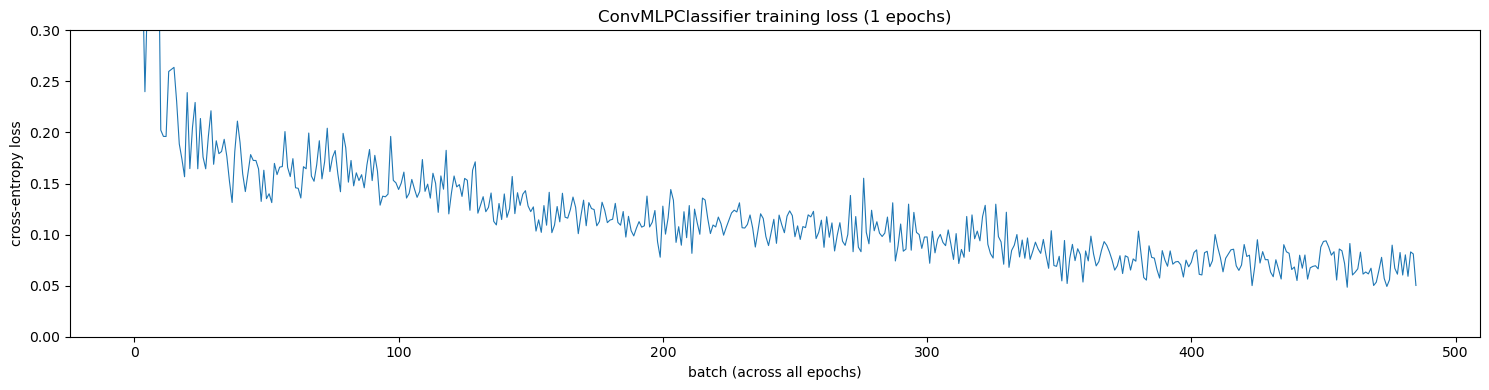

In [97]:
n_per_epoch = len(train_loader)

plt.figure(figsize=(15, 4))
plt.plot(all_loss, linewidth=0.8)
for ep in range(1, NUM_EPOCHS):
    plt.axvline(ep * n_per_epoch, color='grey', linestyle='--', linewidth=0.8)
plt.xlabel('batch (across all epochs)')
plt.ylabel('cross-entropy loss')
plt.title(f'ConvMLPClassifier training loss ({NUM_EPOCHS} epochs)')
plt.ylim(0, 0.3)
plt.tight_layout();

## Validation: F1 Score for Class 3 (exon_end)

We collect predictions over the full validation set and compute precision, recall, and F1 for class 3 directly from true positives (TP), false positives (FP), and false negatives (FN):

$$\text{Precision} = \frac{TP}{TP+FP}, \quad \text{Recall} = \frac{TP}{TP+FN}, \quad F_1 = \frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

In [98]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for x, y, _ in val_loader:
        logits = model(x.to(device))          # (B, L, C)
        preds = logits.argmax(dim=-1)          # (B, L)
        all_preds.append(preds.cpu().reshape(-1))
        all_labels.append(y.reshape(-1))

all_preds  = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

# F1 for class 3 (exon_end) computed from TP, FP, FN
c = 3
tp = ((all_preds == c) & (all_labels == c)).sum().item()
fp = ((all_preds == c) & (all_labels != c)).sum().item()
fn = ((all_preds != c) & (all_labels == c)).sum().item()

precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

print(f'Class {c} (exon_end):')
print(f'  TP={tp}  FP={fp}  FN={fn}')
print(f'  Precision={precision:.3f}  Recall={recall:.3f}  F1={f1:.3f}')

Class 3 (exon_end):
  TP=799  FP=1069  FN=512
  Precision=0.428  Recall=0.609  F1=0.503
